Saving africa_food_waste_unep_2024_observations.csv to africa_food_waste_unep_2024_observations (4).csv
Dataset loaded successfully!
Rows: 49
Columns: 19
Shape:
(49, 19)

Columns:
['observation_id', 'country', 'country_code', 'region', 'study_area', 'source', 'study_year', 'food_waste_kg_capita_year', 'latitude', 'longitude', 'study_scope', 'data_confidence', 'food_waste_kg_capita_month', 'food_waste_kg_capita_day', 'data_type', 'primary_source', 'source_url', 'coordinate_note', 'duplicate_check']

Data types:
observation_id                 object
country                        object
country_code                   object
region                         object
study_area                     object
source                         object
study_year                    float64
food_waste_kg_capita_year       int64
latitude                      float64
longitude                     float64
study_scope                    object
data_confidence                object
food_waste_kg_capita_month  

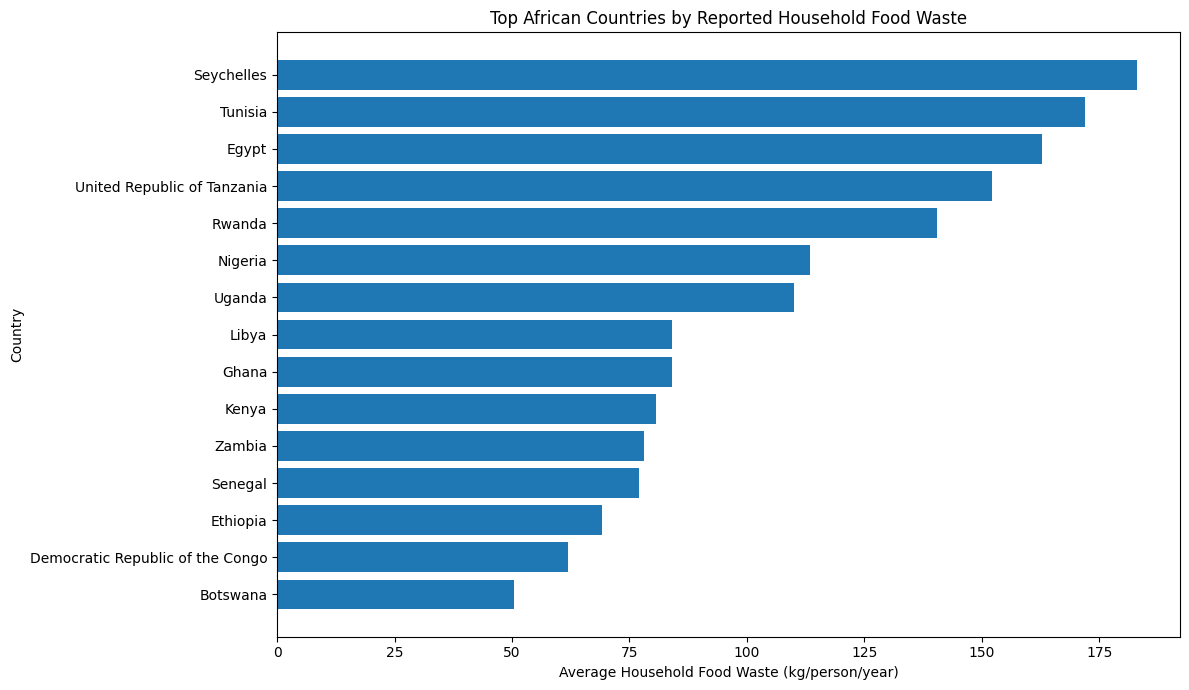

Nigeria observations: 6


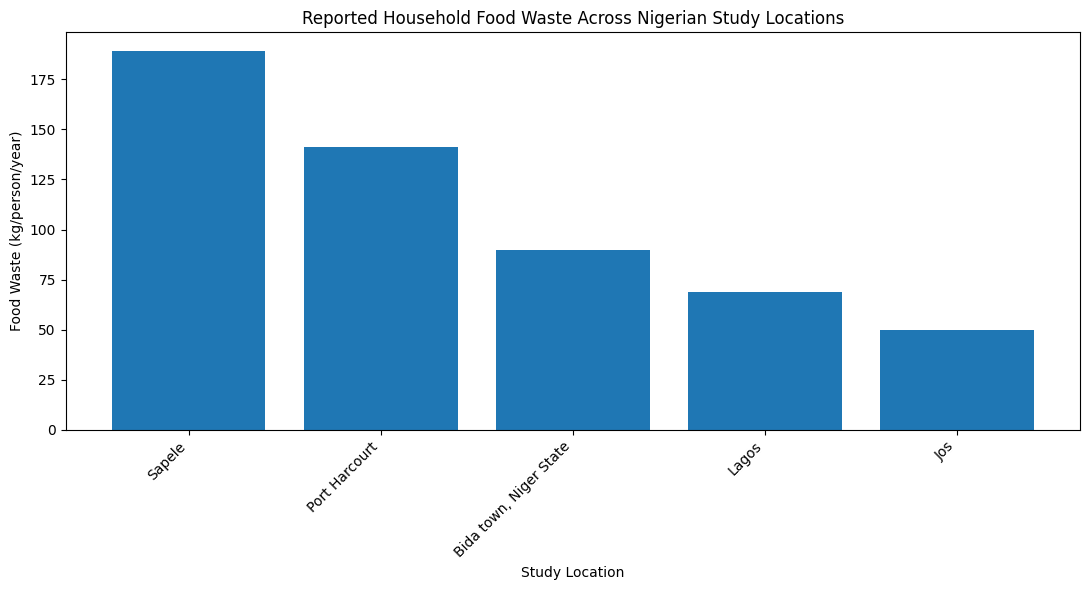

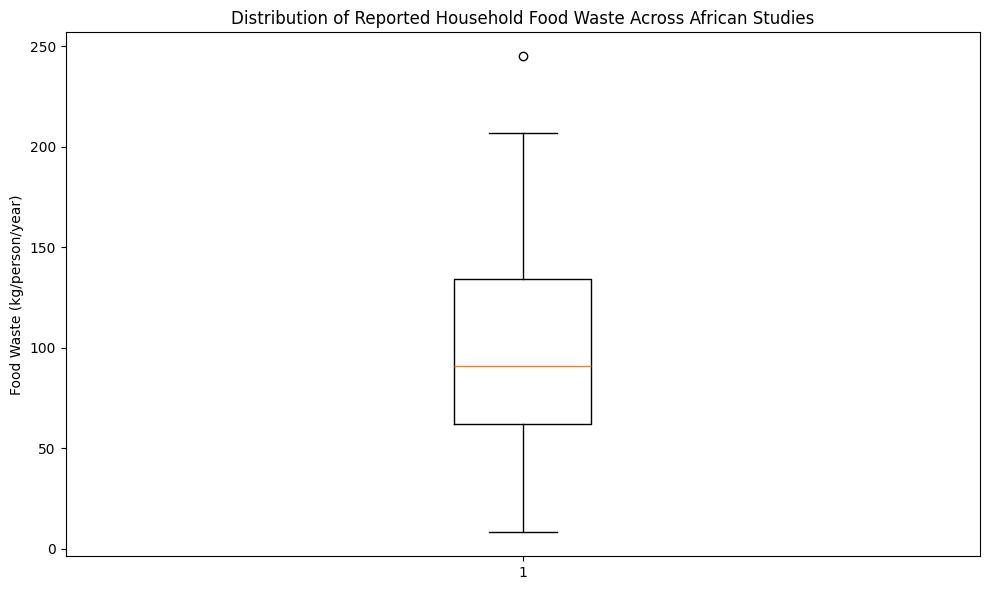

Africa median: 91.0
Nigeria median: 115.5


,study_year,observations,average_waste,median_waste
0,2010.0,1,100.000000,100.0
1,2012.0,2,52.500000,52.5
2,2013.0,3,113.333333,119.0
3,2015.0,1,84.000000,84.0
4,2016.0,2,109.000000,109.0
5,2017.0,2,140.500000,140.5
6,2018.0,2,10.000000,10.0
7,2019.0,3,124.333333,99.0
8,2020.0,8,122.000000,110.5
9,2021.0,11,98.454545,89.0


In [9]:
# ============================================
# UNEP FOOD WASTE ANALYSIS
# Africa & Nigeria
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

unep = pd.read_csv("africa_food_waste_unep_2024_observations.csv")

print("Dataset loaded successfully!")
print("Rows:", unep.shape[0])
print("Columns:", unep.shape[1])

unep.head()

print("Shape:")
print(unep.shape)

print("\nColumns:")
print(unep.columns.tolist())

print("\nData types:")
print(unep.dtypes)

quality = pd.DataFrame({
    "Column": unep.columns,
    "Data_Type": unep.dtypes.astype(str).values,
    "Missing_Values": unep.isna().sum().values,
    "Missing_%": (unep.isna().mean() * 100).round(2).values,
    "Unique_Values": unep.nunique().values
})

quality

print("Total duplicate rows:", unep.duplicated().sum())

numeric_columns = [
    "study_year",
    "food_waste_kg_capita_year",
    "latitude",
    "longitude",
    "food_waste_kg_capita_month",
    "food_waste_kg_capita_day"
]

for col in numeric_columns:
    if col in unep.columns:
        unep[col] = pd.to_numeric(unep[col], errors="coerce")

        unep["food_waste_kg_capita_year"].describe()


## Overall African Food Waste Overview ##
africa_summary = {
    "Total observations": len(unep),
    "Countries": unep["country"].nunique(),
    "Study locations": unep["study_area"].nunique(),
    "Average kg/person/year": unep["food_waste_kg_capita_year"].mean(),
    "Median kg/person/year": unep["food_waste_kg_capita_year"].median(),
    "Minimum kg/person/year": unep["food_waste_kg_capita_year"].min(),
    "Maximum kg/person/year": unep["food_waste_kg_capita_year"].max()
}

pd.Series(africa_summary)

## Food Waste by country ##
country_analysis = (
    unep.groupby("country")
    .agg(
        observations=("observation_id", "count"),
        average_waste_kg=("food_waste_kg_capita_year", "mean"),
        median_waste_kg=("food_waste_kg_capita_year", "median"),
        maximum_waste_kg=("food_waste_kg_capita_year", "max")
    )
    .reset_index()
    .sort_values("average_waste_kg", ascending=False)
)

country_analysis


##  Top Countries by Reported Food Waste ##
top_countries = country_analysis.head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_countries["country"],
    top_countries["average_waste_kg"]
)

plt.xlabel("Average Household Food Waste (kg/person/year)")
plt.ylabel("Country")
plt.title("Top African Countries by Reported Household Food Waste")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Study level Observation ##
study_observations = (
    unep[
        [
            "country",
            "study_area",
            "study_year",
            "food_waste_kg_capita_year",
            "data_confidence",
            "study_scope"
        ]
    ]
    .sort_values("food_waste_kg_capita_year", ascending=False)
)

study_observations.head(20)


## Nigeria Deep Dive ##
nigeria = unep[
    unep["country"].str.strip().str.lower() == "nigeria"
].copy()

print("Nigeria observations:", len(nigeria))

nigeria


## Nigeria Summry ##
nigeria_summary = {
    "Observations": len(nigeria),
    "Study locations": nigeria["study_area"].nunique(),
    "Average kg/person/year": nigeria["food_waste_kg_capita_year"].mean(),
    "Median kg/person/year": nigeria["food_waste_kg_capita_year"].median(),
    "Minimum kg/person/year": nigeria["food_waste_kg_capita_year"].min(),
    "Maximum kg/person/year": nigeria["food_waste_kg_capita_year"].max()
}

pd.Series(nigeria_summary)


## Nigerian locations ##
nigeria_locations = (
    nigeria[
        [
            "study_area",
            "study_year",
            "food_waste_kg_capita_year",
            "food_waste_kg_capita_month",
            "food_waste_kg_capita_day",
            "data_confidence",
            "study_scope"
        ]
    ]
    .sort_values("food_waste_kg_capita_year", ascending=False)
)

nigeria_locations


## Nigerian Visual ##
plt.figure(figsize=(11, 6))

plt.bar(
    nigeria_locations["study_area"],
    nigeria_locations["food_waste_kg_capita_year"]
)

plt.xlabel("Study Location")
plt.ylabel("Food Waste (kg/person/year)")
plt.title("Reported Household Food Waste Across Nigerian Study Locations")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Nigeria VS Africa ##
plt.figure(figsize=(10, 6))

plt.boxplot(
    unep["food_waste_kg_capita_year"].dropna(),
    vert=True
)

plt.ylabel("Food Waste (kg/person/year)")
plt.title("Distribution of Reported Household Food Waste Across African Studies")

plt.tight_layout()
plt.show()

print("Africa median:",
      unep["food_waste_kg_capita_year"].median())

print("Nigeria median:",
      nigeria["food_waste_kg_capita_year"].median())


## Convert annual waste to monthly and daily ##
unep["calculated_monthly"] = (
    unep["food_waste_kg_capita_year"] / 12
)

unep["calculated_daily"] = (
    unep["food_waste_kg_capita_year"] / 365
)

unep[
    [
        "food_waste_kg_capita_year",
        "food_waste_kg_capita_month",
        "calculated_monthly",
        "food_waste_kg_capita_day",
        "calculated_daily"
    ]
].head(10)


## Study year Analysis ##
year_analysis = (
    unep.groupby("study_year")
    .agg(
        observations=("observation_id", "count"),
        average_waste=("food_waste_kg_capita_year", "mean"),
        median_waste=("food_waste_kg_capita_year", "median")
    )
    .reset_index()
    .sort_values("study_year")
)

year_analysis

year_analysis = (
    unep.groupby("study_year")
    .agg(
        observations=("observation_id", "count"),
        average_waste=("food_waste_kg_capita_year", "mean"),
        median_waste=("food_waste_kg_capita_year", "median")
    )
    .reset_index()
    .sort_values("study_year")
)

year_analysis

## Data Confidence Analysis ##
confidence_analysis = (
    unep.groupby("data_confidence")
    .agg(
        observations=("observation_id", "count"),
        average_waste=("food_waste_kg_capita_year", "mean"),
        median_waste=("food_waste_kg_capita_year", "median")
    )
    .reset_index()
    .sort_values("observations", ascending=False)
)

confidence_analysis

plt.figure(figsize=(10, 6))

plt.bar(
    confidence_analysis["data_confidence"].astype(str),
    confidence_analysis["observations"]
)

plt.xlabel("Data Confidence")
plt.ylabel("Number of Observations")
plt.title("UNEP Study Observations by Data Confidence")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Study Scope Analysis ##
scope_analysis = (
    unep.groupby("study_scope")
    .agg(
        observations=("observation_id", "count"),
        average_waste=("food_waste_kg_capita_year", "mean"),
        median_waste=("food_waste_kg_capita_year", "median")
    )
    .reset_index()
    .sort_values("average_waste", ascending=False)
)

scope_analysis


## Geographic Analysis ##
geo_data = unep.dropna(
    subset=["latitude", "longitude"]
).copy()

print("Records with coordinates:", len(geo_data))

plt.figure(figsize=(12, 8))

plt.scatter(
    geo_data["longitude"],
    geo_data["latitude"],
    s=60,
    alpha=0.7
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of UNEP Food-Waste Study Observations")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Geographic plot sized by food waste ##
plt.figure(figsize=(12, 8))

plt.scatter(
    geo_data["longitude"],
    geo_data["latitude"],
    s=geo_data["food_waste_kg_capita_year"].fillna(0) * 2 + 20,
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    "African Food-Waste Study Locations\n"
    "Bubble Size = Reported Food Waste"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Nigeria Geographic Analysis ##
nigeria_geo = nigeria.dropna(
    subset=["latitude", "longitude"]
)

plt.figure(figsize=(10, 7))

plt.scatter(
    nigeria_geo["longitude"],
    nigeria_geo["latitude"],
    s=nigeria_geo["food_waste_kg_capita_year"] * 2 + 30,
    alpha=0.7
)

for _, row in nigeria_geo.iterrows():

    plt.annotate(
        row["study_area"],
        (row["longitude"], row["latitude"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    "UNEP Food-Waste Study Locations in Nigeria"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=unep)

https://docs.google.com/spreadsheets/d/1EGWYf-q3uMoElm7rfMtymfy6Msy3_-Vf9UkR0Z9fLPY/edit#gid=0
